In [1]:
import os, scipy
import matplotlib.pyplot as plt
import numpy as np
from uproot import open as uproot_open
from matplotlib.backends.backend_pdf import PdfPages

In [5]:
# Load root file with uproot from /eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-II/PDS_Commissioning/waffles/2_daq_root givin run number

det = 'HD_PDS'
run = '026360'
mode = 'self_trigger'

#pensar lo de los 0000
root_file = '/eos/experiment/neutplatform/protodune/experiments/ProtoDUNE-II/PDS_Commissioning/waffles/2_daq_root/run_'+run+'/'+run+'_0000.root'
# Load the root file
my_file = uproot_open(root_file)
#Print tree info
print(my_file.keys())
#Load the tree
tree = my_file['raw_waveforms']
#Print the branches
print(tree.keys())
#Load the branches
raw_waveforms = {}
raw_waveforms['adcs'] = tree['adcs'].array()
raw_waveforms['channel'] = tree['channel'].array()
# for key in tree.keys(): raw_waveforms[key] = tree[key].array()


# det       = 'HD_PDS' #LOAD FROM METADATA

['metadata;1', 'raw_waveforms;1']
['channel', 'adcs', 'timestamps', 'repeated_candidate']


In [3]:
# SAVE in map folder?
physical_map = {
                '104': ['10407','10405','10402','10400','10401','10403','10404''10406','10417','10415','10412','10410','10411','10413','10414','10416'],
                '105': ['10507','10505','10502','10500','10501','10503','10504','10506','10526','10524','10523','10521','10501','10512','10515','10517'],
                '107': ['10717','10715','10713','10710','10700','10702','10705','10707'],
                '109': ['10927','10925','10922','10920','10921','10923','10924','10926','10937','10935','10932','10930','10931','10933','10934','10936','10907','10905','10902','10900','10901','10903','10904','10906','10917','10915','10912','10910','10911','10913','10914','10916','10947','10945','10942','10940','10941','10943','10944','10946'],
                '111': ['11106','11104','11103','11101','11131','11133','11134','11136','11107','11105','11102','11100','11130','11132','11135','11137','11146','11144','11143','11141','11111','11113','11114','11116','11117','11115','11112','11110','11121','11123','11124','11126','11147','11145','11142','11140','11120','11122','11125','11127'],
                '112': ['11200','11202','11205','11207','11206','11204','11203','11201','11210','11212','11215','11217','11216','11214','11213','11211','11227','11225','11222','11220','11221','11223','11224','11226','11237','11235','11232','11230','11231','11233','11234','11236','11247','11245','11242','11240'],
                '113': ['11300','11302','11305','11307']
                }

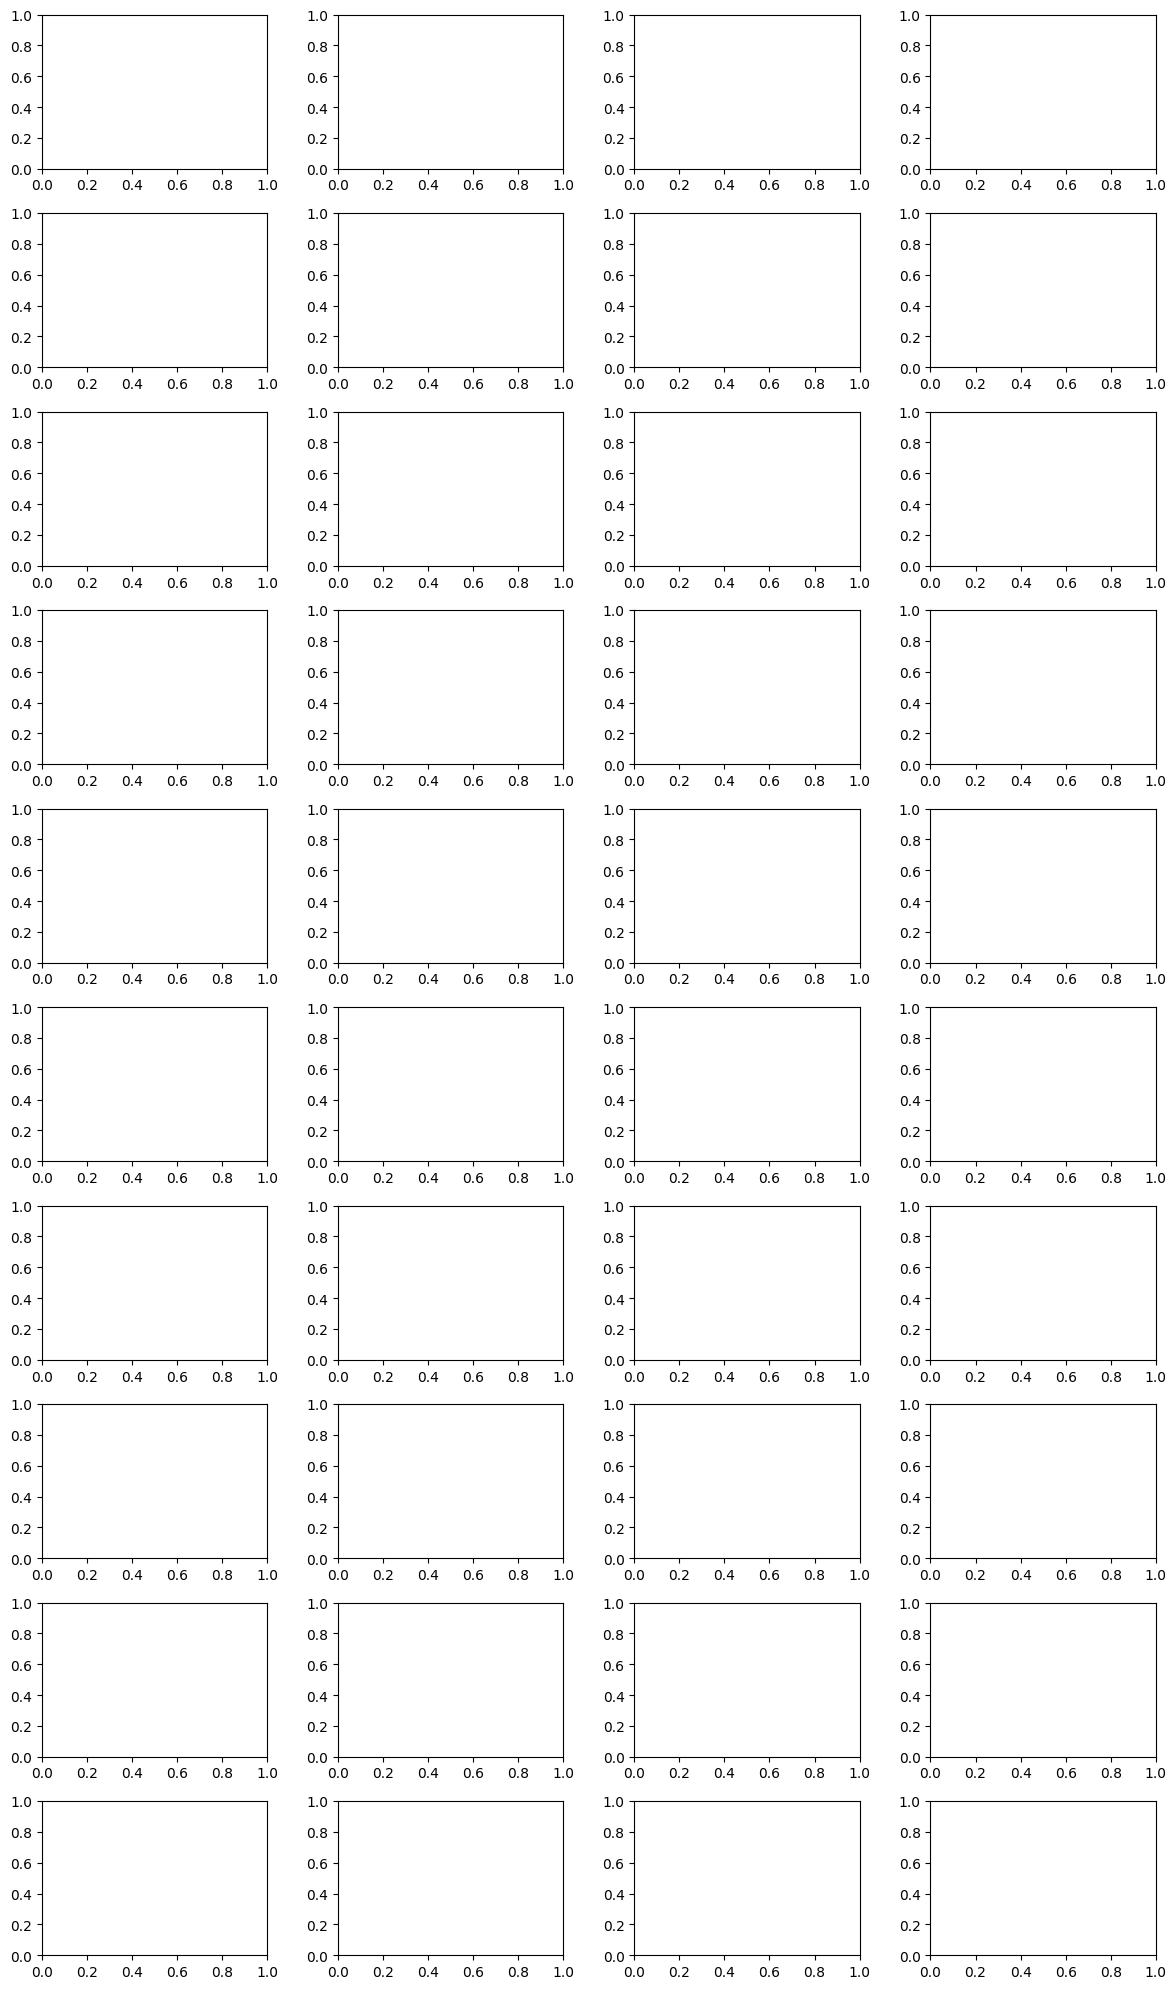

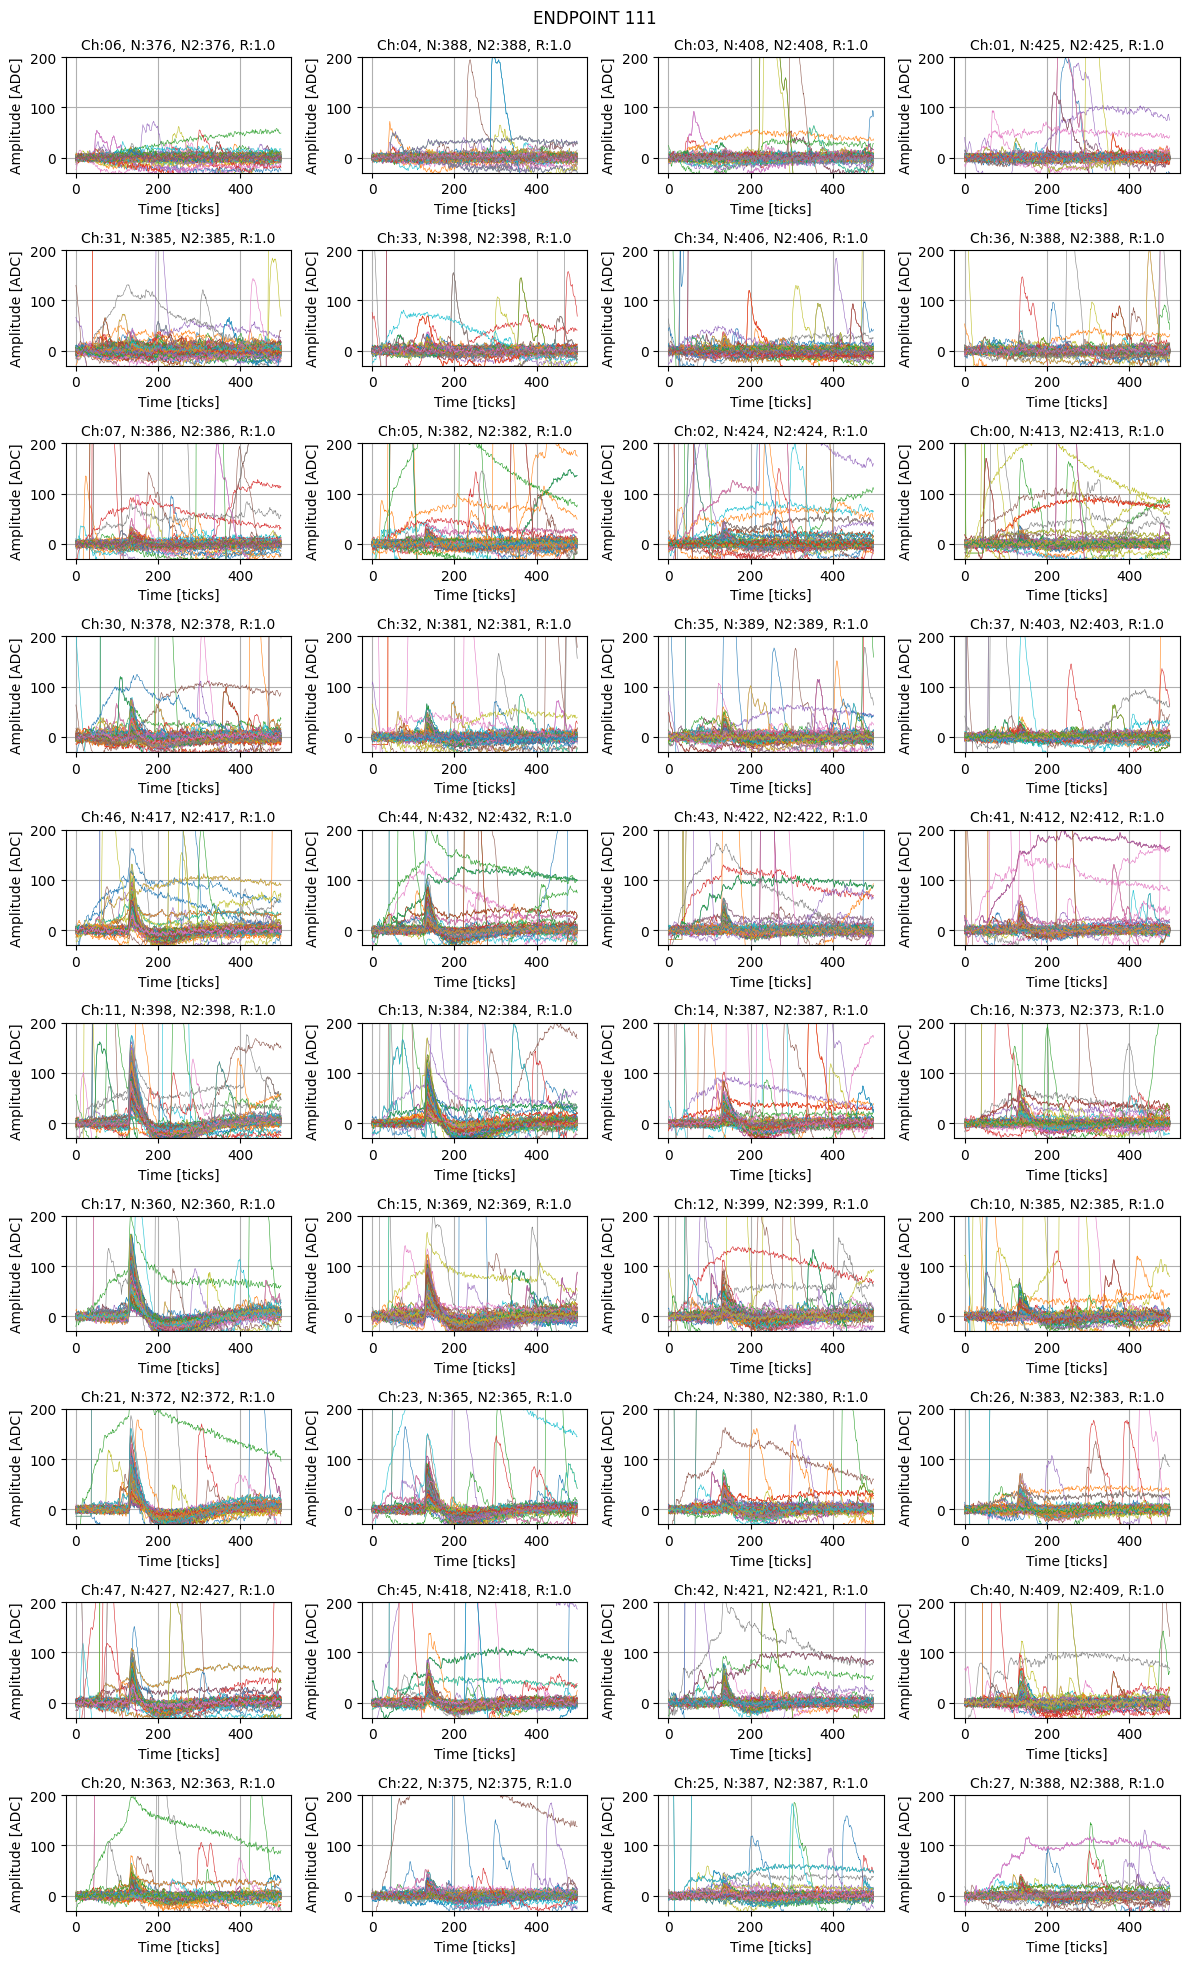

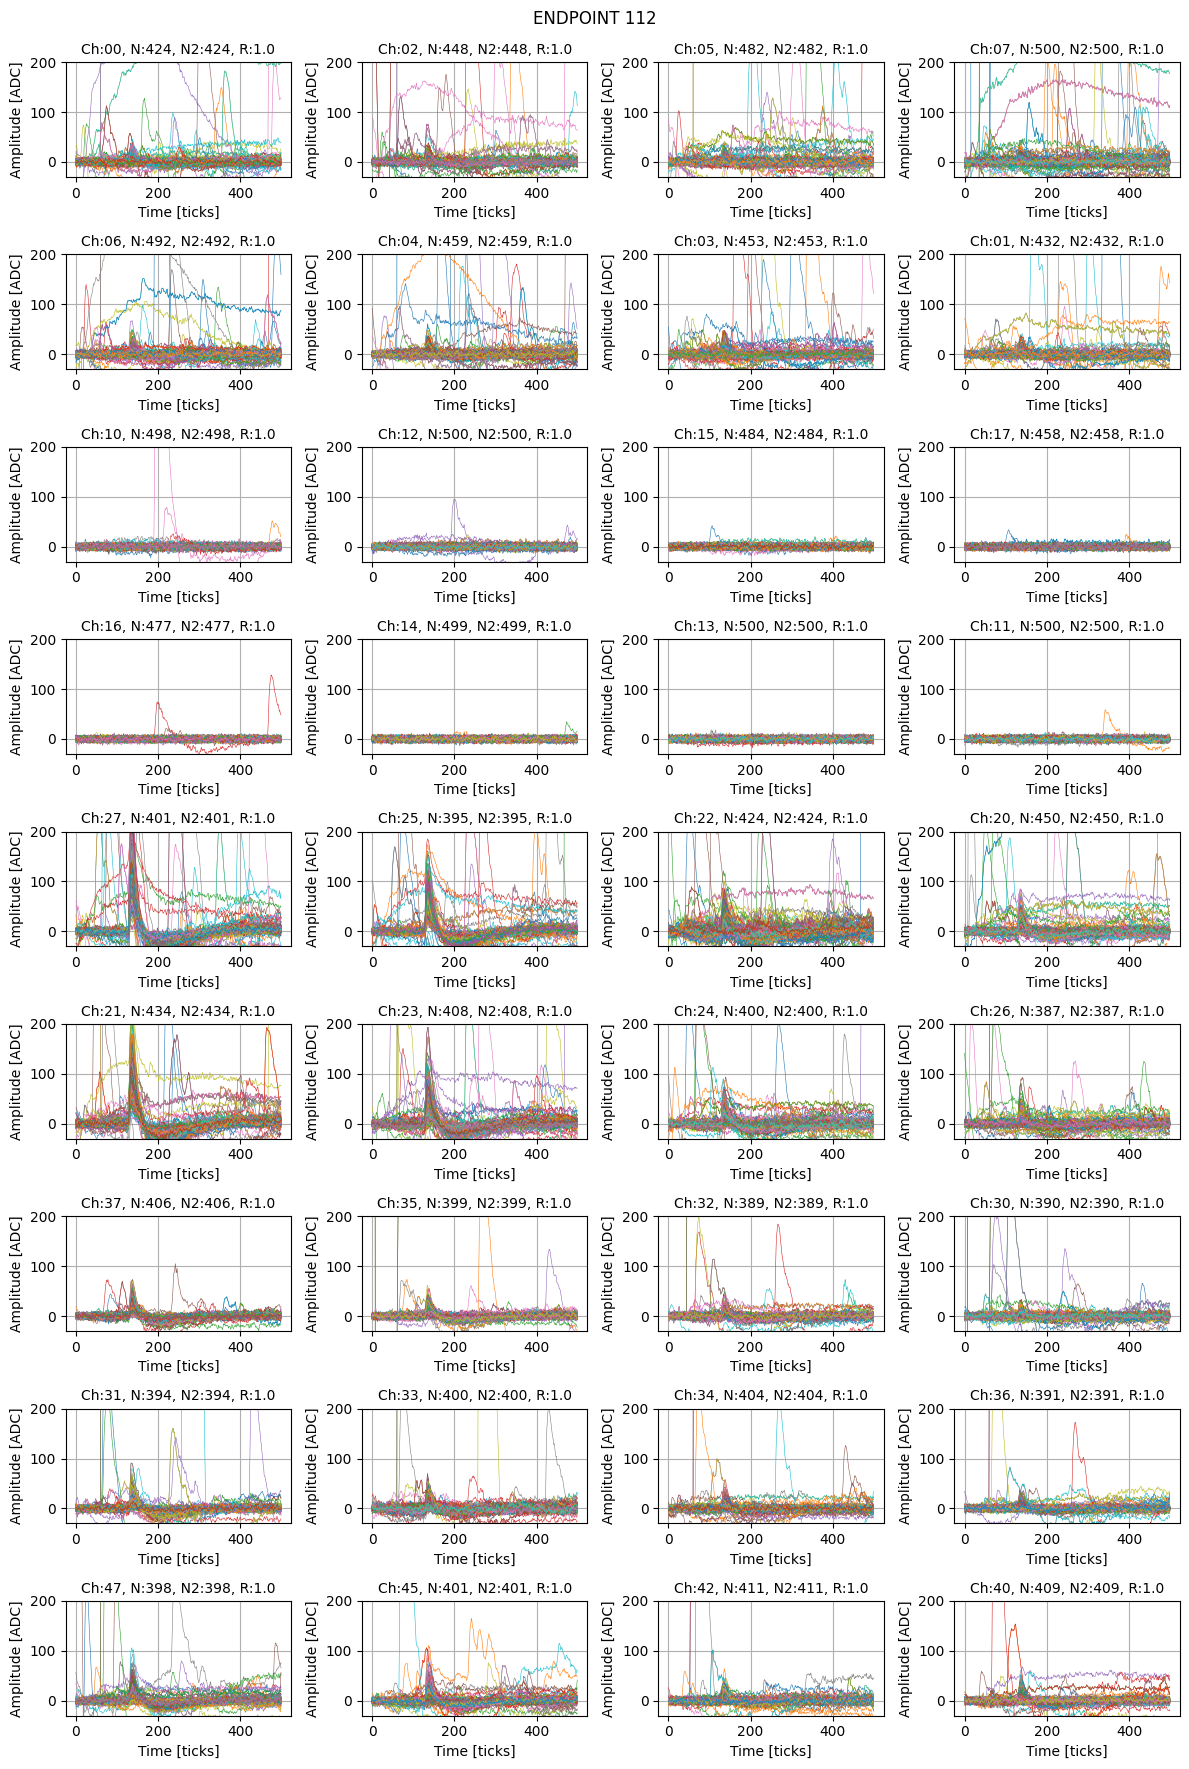

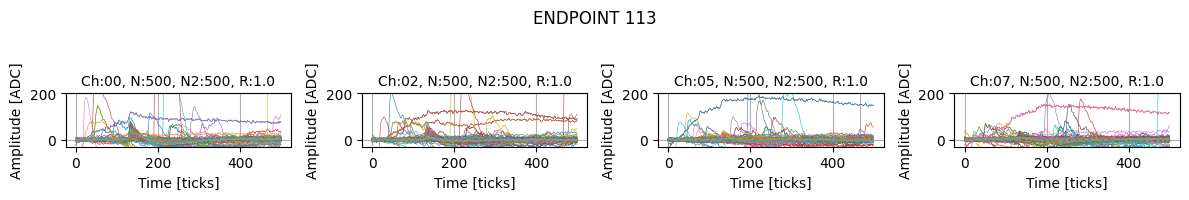

In [6]:
ep     = '112' # Enpoint to plot
nwvfs  = 500   # Number of waveforms to plot
ncols  = 4     # Number of columns in your subplot
sv_pdf = False  # Save pdf with plots

for ep in ['109','111','112','113']:
    if sv_pdf: pdf_pages = PdfPages(f'images/ip{ep}_wvfs.pdf')
    fig, ax = plt.subplots(int(len(physical_map[ep])/ncols), ncols, figsize=(12,2*int(len(physical_map[ep])/ncols)))
    ax = ax.flatten()
    for ch,channel in enumerate(physical_map[ep]):
        ch_idx = np.where(raw_waveforms['channel']==int(channel))[0]
        raw_wf = raw_waveforms['adcs'][ch_idx][:nwvfs]
        nwf_cut=0
        if len(raw_wf) > 0:
            for w in raw_wf:
                # if 500<np.max(np.multiply(w-w[:40].mean(),-1))<1000:
                w_p = np.multiply(w-np.mean(w[:40]),-1)
                if np.max(w_p) < 16 and np.max(w_p) > 60: continue
                #peaks, prop=scipy.signal.find_peaks(w_p, threshold=8)
                #if len(peaks): print (peaks)
                nwf_cut+=1
                ax[ch].plot(w_p[0:500],linewidth=0.4)
                ax[ch].set_ylim(-30,200)                
                ax[ch].set_ylabel('Amplitude [ADC]')
                ax[ch].set_xlabel('Time [ticks]')
                #ax[ch].legend()
                ax[ch].grid(True)
            fig.suptitle(f'ENDPOINT {(ep)}\n', fontsize=12)
            fig.subplots_adjust(top=0.9)
            ax[ch].set_title(f'Ch:{channel[3:]}, N:{len(raw_wf)}, N2:{nwf_cut}, R:{round(nwf_cut/len(raw_wf),2)}', fontsize=10)
    fig.tight_layout()
    plt.show()
    if sv_pdf: 
        pdf_pages.savefig(fig)
        pdf_pages.close()
    plt.close(fig)
    del raw_wf